In [ ]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Copy zip file to Colab
!cp /content/drive/MyDrive/15298010.zip /content/

# Unzip
!unzip /content/15298010.zip -d /content/15298010


Archive:  /content/15298010.zip
 extracting: /content/15298010/images.zip  
 extracting: /content/15298010/masks.zip  


In [ ]:
#images and masks are present
!ls /content/15298010


images.zip  masks.zip


In [ ]:
!unzip /content/15298010/images.zip -d /content/15298010/images


Streaming output truncated to the last 5000 lines.
  inflating: /content/15298010/images/images/train/sentinel_555.png  
  inflating: /content/15298010/images/__MACOSX/images/train/._sentinel_555.png  
  inflating: /content/15298010/images/images/train/sentinel_2145.png  
  inflating: /content/15298010/images/__MACOSX/images/train/._sentinel_2145.png  
  inflating: /content/15298010/images/images/train/palsar_2465.png  
  inflating: /content/15298010/images/__MACOSX/images/train/._palsar_2465.png  
  inflating: /content/15298010/images/images/train/palsar_2303.png  
  inflating: /content/15298010/images/__MACOSX/images/train/._palsar_2303.png  
  inflating: /content/15298010/images/images/train/sentinel_2623.png  
  inflating: /content/15298010/images/__MACOSX/images/train/._sentinel_2623.png  
  inflating: /content/15298010/images/images/train/sentinel_2637.png  
  inflating: /content/15298010/images/__MACOSX/images/train/._sentinel_2637.png  
  inflating: /content/15298010/images/ima

In [ ]:
!unzip /content/15298010/masks.zip -d /content/15298010/masks


Streaming output truncated to the last 5000 lines.
  inflating: /content/15298010/masks/masks/train/sentinel_555.png  
  inflating: /content/15298010/masks/__MACOSX/masks/train/._sentinel_555.png  
  inflating: /content/15298010/masks/masks/train/sentinel_2145.png  
  inflating: /content/15298010/masks/__MACOSX/masks/train/._sentinel_2145.png  
  inflating: /content/15298010/masks/masks/train/palsar_2465.png  
  inflating: /content/15298010/masks/__MACOSX/masks/train/._palsar_2465.png  
  inflating: /content/15298010/masks/masks/train/palsar_2303.png  
  inflating: /content/15298010/masks/__MACOSX/masks/train/._palsar_2303.png  
  inflating: /content/15298010/masks/masks/train/sentinel_2623.png  
  inflating: /content/15298010/masks/__MACOSX/masks/train/._sentinel_2623.png  
  inflating: /content/15298010/masks/masks/train/sentinel_2637.png  
  inflating: /content/15298010/masks/__MACOSX/masks/train/._sentinel_2637.png  
  inflating: /content/15298010/masks/masks/train/palsar_2317.png 

In [ ]:
#ensure that 'images' and 'masks' folders (with train/val splits) exist correctly
!find /content/15298010 -maxdepth 4 -type d


/content/15298010
/content/15298010/images
/content/15298010/images/images
/content/15298010/images/images/val
/content/15298010/images/images/train
/content/15298010/images/__MACOSX
/content/15298010/images/__MACOSX/images
/content/15298010/images/__MACOSX/images/val
/content/15298010/images/__MACOSX/images/train
/content/15298010/masks
/content/15298010/masks/__MACOSX
/content/15298010/masks/__MACOSX/masks
/content/15298010/masks/__MACOSX/masks/val
/content/15298010/masks/__MACOSX/masks/train
/content/15298010/masks/masks
/content/15298010/masks/masks/val
/content/15298010/masks/masks/train


In [ ]:
!ls /content/15298010/images/images/train | head
!ls /content/15298010/masks/masks/train | head

!ls /content/15298010/images/images/val | head
!ls /content/15298010/masks/masks/val | head


palsar_0.png
palsar_1000.png
palsar_1001.png
palsar_1002.png
palsar_1003.png
palsar_1004.png
palsar_1005.png
palsar_1006.png
palsar_1007.png
palsar_1008.png
palsar_0.png
palsar_1000.png
palsar_1001.png
palsar_1002.png
palsar_1003.png
palsar_1004.png
palsar_1005.png
palsar_1006.png
palsar_1007.png
palsar_1008.png
palsar_0.png
palsar_100.png
palsar_101.png
palsar_102.png
palsar_103.png
palsar_104.png
palsar_105.png
palsar_106.png
palsar_107.png
palsar_108.png
palsar_0.png
palsar_100.png
palsar_101.png
palsar_102.png
palsar_103.png
palsar_104.png
palsar_105.png
palsar_106.png
palsar_107.png
palsar_108.png


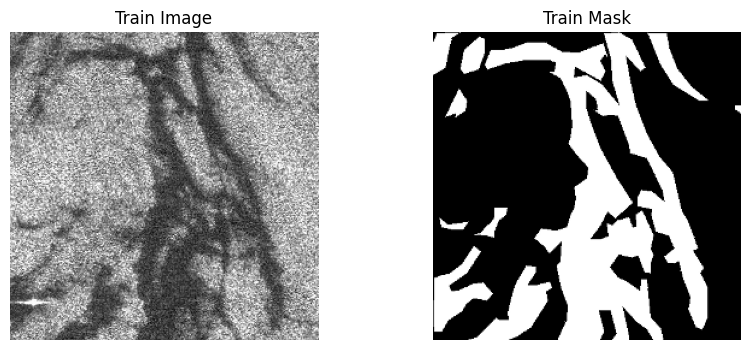

In [ ]:
#sanity check
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

img_dir = "/content/15298010/images/images/train"
mask_dir = "/content/15298010/masks/masks/train"

img_files = sorted(os.listdir(img_dir))
mask_files = sorted(os.listdir(mask_dir))

idx = np.random.randint(0, len(img_files))

img = cv2.imread(os.path.join(img_dir, img_files[idx]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(os.path.join(mask_dir, mask_files[idx]), 0)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Train Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Train Mask")
plt.axis("off")

plt.show()


In [ ]:
!pip install -q albumentations segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch
from torch.utils.data import Dataset, DataLoader


In [ ]:
#base directories
BASE_PATH = "/content/15298010"

TRAIN_IMG = os.path.join(BASE_PATH, "images/images/train")
TRAIN_MASK = os.path.join(BASE_PATH, "masks/masks/train")

VAL_IMG = os.path.join(BASE_PATH, "images/images/val")
VAL_MASK = os.path.join(BASE_PATH, "masks/masks/val")


In [ ]:
class OilSpillDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)
        mask = (mask > 0).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].unsqueeze(0)

        return image, mask


In [ ]:
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2()
])


In [ ]:
train_dataset = OilSpillDataset(TRAIN_IMG, TRAIN_MASK, train_transform)
val_dataset   = OilSpillDataset(VAL_IMG, VAL_MASK, val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("DataLoaders ready")


DataLoaders ready


In [ ]:
import os

def count_files(path):
    return len(os.listdir(path))

print("Train Images:", count_files("/content/15298010/images/images/train"))
print("Train Masks :", count_files("/content/15298010/masks/masks/train"))

print("Val Images  :", count_files("/content/15298010/images/images/val"))
print("Val Masks   :", count_files("/content/15298010/masks/masks/val"))


Train Images: 6455
Train Masks : 6455
Val Images  : 1615
Val Masks   : 1615


In [ ]:
import os
import cv2
import numpy as np

TRAIN_MASK_DIR = "/content/15298010/masks/masks/train"
VAL_MASK_DIR   = "/content/15298010/masks/masks/val"



In [ ]:
def count_oil_non_oil(mask_dir):
    oil = 0
    non_oil = 0

    for mask_file in os.listdir(mask_dir):
        mask_path = os.path.join(mask_dir, mask_file)
        mask = cv2.imread(mask_path, 0)

        # Check if any oil pixel exists
        if np.any(mask > 0):
            oil += 1
        else:
            non_oil += 1

    return oil, non_oil

train_oil, train_non_oil = count_oil_non_oil(TRAIN_MASK_DIR)
val_oil, val_non_oil     = count_oil_non_oil(VAL_MASK_DIR)

print("🔹 TRAIN SET")
print("Oil Spill Images     :", train_oil)
print("Non-Oil Images       :", train_non_oil)

print("\n🔹 VALIDATION SET")
print("Oil Spill Images     :", val_oil)
print("Non-Oil Images       :", val_non_oil)

print("\n🔹 TOTAL DATASET")
print("Oil Spill Images     :", train_oil + val_oil)
print("Non-Oil Images       :", train_non_oil + val_non_oil)



🔹 TRAIN SET
Oil Spill Images     : 6206
Non-Oil Images       : 249

🔹 VALIDATION SET
Oil Spill Images     : 1539
Non-Oil Images       : 76

🔹 TOTAL DATASET
Oil Spill Images     : 7745
Non-Oil Images       : 325


In [ ]:

sizes = []

for img in os.listdir(TRAIN_IMG):
    img_path = os.path.join(TRAIN_IMG, img)
    image = cv2.imread(img_path)
    h, w, _ = image.shape
    sizes.append((h, w))

print("Unique image sizes:", set(sizes))


Unique image sizes: {(256, 256)}


In [ ]:
import numpy as np

oil_pixels = []
total_pixels = []

for mask_file in os.listdir(TRAIN_MASK):
    mask = cv2.imread(os.path.join(TRAIN_MASK, mask_file), 0)
    oil_pixels.append(np.sum(mask > 0))
    total_pixels.append(mask.size)

oil_percentage = np.array(oil_pixels) / np.array(total_pixels)

print("Average oil coverage:", np.mean(oil_percentage) * 100, "%")


Average oil coverage: 25.689982348500433 %


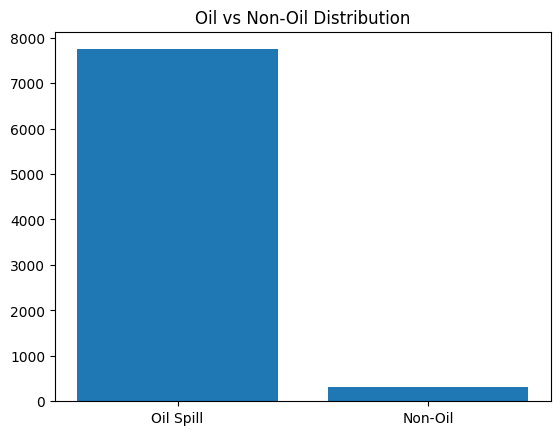

In [ ]:
import matplotlib.pyplot as plt

labels = ['Oil Spill', 'Non-Oil']
counts = [train_oil + val_oil, train_non_oil + val_non_oil]

plt.bar(labels, counts)
plt.title("Oil vs Non-Oil Distribution")
plt.show()


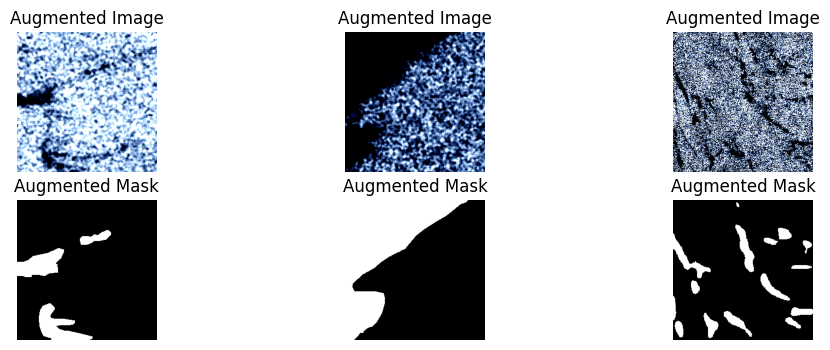

In [ ]:
images, masks = next(iter(train_loader))

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title("Augmented Image")
    plt.axis("off")

    plt.subplot(2,3,i+4)
    plt.imshow(masks[i][0], cmap="gray")
    plt.title("Augmented Mask")
    plt.axis("off")

plt.show()


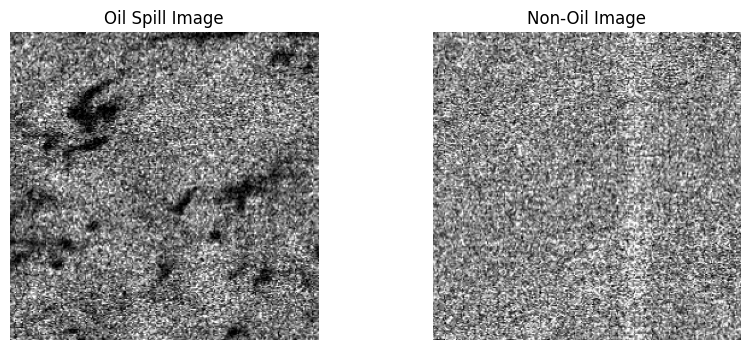

In [ ]:
#To visually compare an image that contains an oil spill with an image that does not contain an oil spill.
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

def get_oil_and_non_oil(mask_dir, img_dir):
    oil_img = non_oil_img = None

    for file in os.listdir(mask_dir):
        mask = cv2.imread(os.path.join(mask_dir, file), 0)
        img = cv2.imread(os.path.join(img_dir, file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if np.any(mask > 0) and oil_img is None:
            oil_img = img
        elif not np.any(mask > 0) and non_oil_img is None:
            non_oil_img = img

        if oil_img is not None and non_oil_img is not None:
            break

    return oil_img, non_oil_img

oil_img, non_oil_img = get_oil_and_non_oil(
    "/content/15298010/masks/masks/train",
    "/content/15298010/images/images/train"
)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(oil_img)
plt.title("Oil Spill Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(non_oil_img)
plt.title("Non-Oil Image")
plt.axis("off")

plt.show()


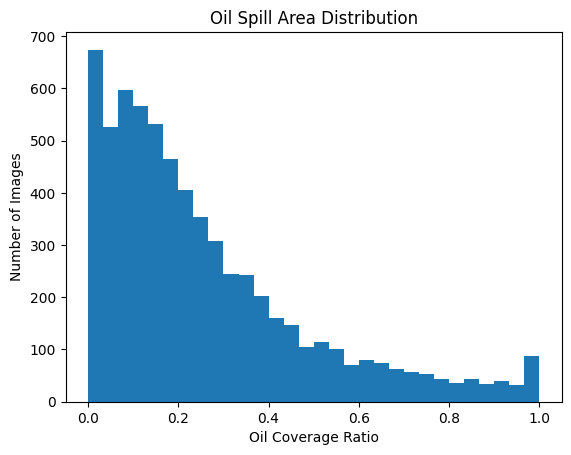

In [ ]:
#To analyze how much oil spill area is present in each training image and understand its distribution across the dataset
import numpy as np

coverages = []

for mask_file in os.listdir("/content/15298010/masks/masks/train"):
    mask = cv2.imread(
        os.path.join("/content/15298010/masks/masks/train", mask_file), 0
    )
    coverage = np.sum(mask > 0) / mask.size
    coverages.append(coverage)

plt.hist(coverages, bins=30)
plt.title("Oil Spill Area Distribution")
plt.xlabel("Oil Coverage Ratio")
plt.ylabel("Number of Images")
plt.show()


In [ ]:
#Model Defination

import segmentation_models_pytorch as smp
import torch

# Device (GPU if available)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Define the model
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(DEVICE)

print("Model loaded on:", DEVICE)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model loaded on: cuda


In [ ]:
#Loss Function + Optimizer

import segmentation_models_pytorch as smp
import torch

dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss  = smp.losses.SoftBCEWithLogitsLoss()

def loss_fn(pred, target):
    return dice_loss(pred, target) + bce_loss(pred, target)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Loss function and optimizer initialized")


Loss function and optimizer initialized


In [ ]:
#Training the Model

from tqdm import tqdm

EPOCHS = 5   # small number on purpose

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_fn(outputs, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.4f}")


Epoch 1/5: 100%|██████████| 807/807 [02:01<00:00,  6.64it/s]


Epoch [1/5] - Train Loss: 0.5899


Epoch 2/5: 100%|██████████| 807/807 [01:59<00:00,  6.74it/s]


Epoch [2/5] - Train Loss: 0.4434


Epoch 3/5: 100%|██████████| 807/807 [01:59<00:00,  6.73it/s]


Epoch [3/5] - Train Loss: 0.4066


Epoch 4/5: 100%|██████████| 807/807 [02:00<00:00,  6.72it/s]


Epoch [4/5] - Train Loss: 0.3838


Epoch 5/5: 100%|██████████| 807/807 [01:59<00:00,  6.73it/s]

Epoch [5/5] - Train Loss: 0.3776


In [ ]:
torch.save(model.state_dict(), "oil_spill_unet.pth")
print("Model saved successfully")


Model saved successfully


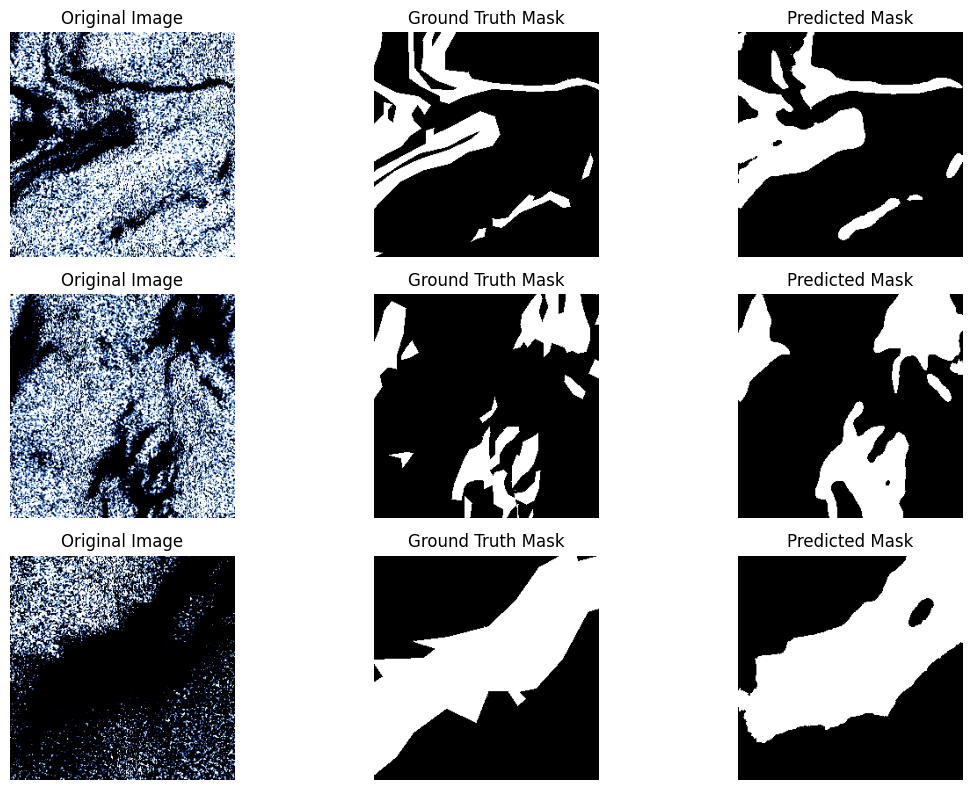

In [ ]:
#Visualization of Results

import matplotlib.pyplot as plt
import torch

# Put model in evaluation mode
model.eval()

# Get one batch from validation loader
images, masks = next(iter(val_loader))

images = images.to(DEVICE)
masks  = masks.to(DEVICE)

with torch.no_grad():
    preds = model(images)
    preds = torch.sigmoid(preds)          # convert logits to probabilities
    preds = (preds > 0.5).float()          # binary mask

# Move tensors to CPU for plotting
images = images.cpu()
masks  = masks.cpu()
preds  = preds.cpu()

# Visualize first 3 samples
plt.figure(figsize=(12,8))

for i in range(3):
    # Original image
    plt.subplot(3, 3, i*3 + 1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title("Original Image")
    plt.axis("off")

    # Ground truth mask
    plt.subplot(3, 3, i*3 + 2)
    plt.imshow(masks[i][0], cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    # Predicted mask
    plt.subplot(3, 3, i*3 + 3)
    plt.imshow(preds[i][0], cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
#Quantative Evaluation

import torch
import numpy as np

def dice_score(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

model.eval()

dice_scores = []
iou_scores = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        outputs = model(images)
        outputs = torch.sigmoid(outputs)
        preds = (outputs > 0.5).float()

        for i in range(preds.size(0)):
            dice = dice_score(preds[i], masks[i])
            iou  = iou_score(preds[i], masks[i])

            dice_scores.append(dice.item())
            iou_scores.append(iou.item())

print("Validation Dice Score:", np.mean(dice_scores))
print("Validation IoU Score :", np.mean(iou_scores))


Validation Dice Score: 0.80126905106309
Validation IoU Score : 0.7009450544843748
